In [1]:
import sys
from pathlib import Path

dynapse_path = Path.home() / "NI_project" / "dynap-se1"
sys.path.append(str(dynapse_path))

import samna
import numpy as np
import matplotlib.pyplot as plt
import samna.dynapse1 as dyn1

import dynapse1utils as ut
from netgen import Neuron, NetworkGenerator

import params
from params import set_params

import time
from IPython.display import Image

In [ ]:
# open DYNAP-SE1 board to get Dynapse1Model

# The open_dynapse1 utility will initialize communication with the device
# - gui=False: do not open any graphical interface --> the DYNAPSE1 GUI does not work if you connect remotely
# - select_device=True: allow user/device selection if multiple boards are detected --> this is necessary when you are connecting via Zemo, since there is more than 1 board attached

model, _ = ut.open_dynapse1(gui=False, select_device=True)

# model = ut.open_specific_device_in_sequence(2)


In [2]:
model, _ = ut.open_dynapse1()

[0]:  Bus 1 Device 2 Dynapse1DevKit serial_number 00000001
0 Dynapse1Wrapper created! libcaer init...
Selected device: 00000001
Sender port: tcp://0.0.0.0:39001
Receiver port: tcp://0.0.0.0:49921
Opened device name: Dynapse1DevKit
SamnaNode ID: 1
PythonNode ID: 2
Clearing chip 0... DONE.
Clearing chip 1... DONE.
Clearing chip 2... DONE.
Clearing chip 3... DONE.


### Initialize Dynap-SE

In [421]:
api = model.get_dynapse1_api()          # get Dynapse1 api from the model
set_params(model)                       # set standard parameters

config1     = model.get_configuration() 
param_group = config1.chips[0].cores[0].parameter_group 

### **Set Neuron/Dendrite Parameters**

In [422]:
# set AMPA (fast excitatory) weight 
param_group.param_map['PS_WEIGHT_EXC_F_N'].fine_value   = 110
param_group.param_map['PS_WEIGHT_EXC_F_N'].coarse_value = 5

# set NMDA (slow excitatory) weight
param_group.param_map['PS_WEIGHT_EXC_S_N'].fine_value   = 70
param_group.param_map['PS_WEIGHT_EXC_S_N'].coarse_value = 5

# set GABA B (slow inhibitory) weight
param_group.param_map['PS_WEIGHT_INH_S_N'].fine_value   = 25
param_group.param_map['PS_WEIGHT_INH_S_N'].coarse_value = 5

# set GABA A (fast inhibitory) weight
param_group.param_map['PS_WEIGHT_INH_F_N'].fine_value   = 70
param_group.param_map['PS_WEIGHT_INH_F_N'].coarse_value = 5

# set AMPA (fast exc) tau 
param_group.param_map['NPDPIE_TAU_F_P'].fine_value   = 80
param_group.param_map['NPDPIE_TAU_F_P'].coarse_value = 4

# set NMDA (slow exc) tau   
# remember the higher the tau param, the higher the leak, the faster the decay
param_group.param_map['NPDPIE_TAU_S_P'].fine_value   = 80
param_group.param_map['NPDPIE_TAU_S_P'].coarse_value = 4

# set Input DC Bias Current (Baseline = 0)
param_group.param_map['IF_DC_P'].fine_value   = 100
param_group.param_map['IF_DC_P'].coarse_value = 2

# Neuron membrane voltage gain
param_group.param_map['IF_THR_N'].fine_value = 150  # before 120
param_group.param_map['IF_THR_N'].coarse_value = 5

In [423]:
# set AMPA (fast excitatory) weight 
param_group.param_map['PS_WEIGHT_EXC_F_N'].fine_value   = 110
param_group.param_map['PS_WEIGHT_EXC_F_N'].coarse_value = 5

# set NMDA (slow excitatory) weight
param_group.param_map['PS_WEIGHT_EXC_S_N'].fine_value   = 70
param_group.param_map['PS_WEIGHT_EXC_S_N'].coarse_value = 5

# set GABA B (slow inhibitory) weight
param_group.param_map['PS_WEIGHT_INH_S_N'].fine_value   = 25
param_group.param_map['PS_WEIGHT_INH_S_N'].coarse_value = 5

# set GABA A (fast inhibitory) weight
param_group.param_map['PS_WEIGHT_INH_F_N'].fine_value   = 70
param_group.param_map['PS_WEIGHT_INH_F_N'].coarse_value = 5

# set AMPA (fast exc) tau 
param_group.param_map['NPDPIE_TAU_F_P'].fine_value   = 70
param_group.param_map['NPDPIE_TAU_F_P'].coarse_value = 4

# set NMDA (slow exc) tau   
# remember the higher the tau param, the higher the leak, the faster the decay
param_group.param_map['NPDPIE_TAU_S_P'].fine_value   = 80
param_group.param_map['NPDPIE_TAU_S_P'].coarse_value = 4

# set Input DC Bias Current (Baseline = 0)
param_group.param_map['IF_DC_P'].fine_value   = 50
param_group.param_map['IF_DC_P'].coarse_value = 1

# Neuron membrane voltage gain
param_group.param_map['IF_THR_N'].fine_value = 130  # before 120
param_group.param_map['IF_THR_N'].coarse_value = 4

In [424]:
# print AMPA weight values

print("\n--- AMPA (fast excitatory) weight ---")
print("Linear: " + str(config1.chips[0].cores[0].parameter_group.get_linear_parameter('PS_WEIGHT_EXC_F_N')))
print("Coarse: " + str(config1.chips[0].cores[0].parameter_group.param_map['PS_WEIGHT_EXC_F_N'].coarse_value))
print("Fine: "   + str(config1.chips[0].cores[0].parameter_group.param_map['PS_WEIGHT_EXC_F_N'].fine_value))


# print NMDA (slow excitatory) weight

print("\n--- NMDA (slow excitatory) weight ---")
print("Linear: " + str(config1.chips[0].cores[0].parameter_group.get_linear_parameter('PS_WEIGHT_EXC_S_N')))
print("Coarse: " + str(config1.chips[0].cores[0].parameter_group.param_map['PS_WEIGHT_EXC_S_N'].coarse_value))
print("Fine: "   + str(config1.chips[0].cores[0].parameter_group.param_map['PS_WEIGHT_EXC_S_N'].fine_value))


# print GABA B (slow inhibitory) weight

print("\n--- GABA B (slow inhibitory) weight ---")
print("Linear: " + str(config1.chips[0].cores[0].parameter_group.get_linear_parameter('PS_WEIGHT_INH_S_N')))
print("Coarse: " + str(config1.chips[0].cores[0].parameter_group.param_map['PS_WEIGHT_INH_S_N'].coarse_value))
print("Fine: "   + str(config1.chips[0].cores[0].parameter_group.param_map['PS_WEIGHT_INH_S_N'].fine_value))


# print GABA A (fast inhibitory) weight

print("\n--- GABA A (fast inhibitory) weight ---")
print("Linear: " + str(config1.chips[0].cores[0].parameter_group.get_linear_parameter('PS_WEIGHT_INH_F_N')))
print("Coarse: " + str(config1.chips[0].cores[0].parameter_group.param_map['PS_WEIGHT_INH_F_N'].coarse_value))
print("Fine: "   + str(config1.chips[0].cores[0].parameter_group.param_map['PS_WEIGHT_INH_F_N'].fine_value))


# print NMDA (slow exc) tau

print("\n--- NMDA tau (slow excitatory) ---")
print("Linear: " + str(config1.chips[0].cores[0].parameter_group.get_linear_parameter('NPDPIE_TAU_S_P')))
print("Coarse: " + str(config1.chips[0].cores[0].parameter_group.param_map['NPDPIE_TAU_S_P'].coarse_value))
print("Fine: "   + str(config1.chips[0].cores[0].parameter_group.param_map['NPDPIE_TAU_S_P'].fine_value))


# print AMPA (fast exc) tau

print("\n--- AMPA tau (fast excitatory) ---")
print("Linear: " + str(config1.chips[0].cores[0].parameter_group.get_linear_parameter('NPDPIE_TAU_F_P')))
print("Coarse: " + str(config1.chips[0].cores[0].parameter_group.param_map['NPDPIE_TAU_F_P'].coarse_value))
print("Fine: "   + str(config1.chips[0].cores[0].parameter_group.param_map['NPDPIE_TAU_F_P'].fine_value))


--- AMPA (fast excitatory) weight ---
Linear: 17254902.0
Coarse: 5
Fine: 110

--- NMDA (slow excitatory) weight ---
Linear: 10980392.0
Coarse: 5
Fine: 70

--- GABA B (slow inhibitory) weight ---
Linear: 3921569.0
Coarse: 5
Fine: 25

--- GABA A (fast inhibitory) weight ---
Linear: 10980392.0
Coarse: 5
Fine: 70

--- NMDA tau (slow excitatory) ---
Linear: 1568628.0
Coarse: 4
Fine: 80

--- AMPA tau (fast excitatory) ---
Linear: 1372549.0
Coarse: 4
Fine: 70


### **Set Network Parameters**

In [425]:

model.update_parameter_group(param_group, 0, 0)

NE = 16          # neurons per excitatory state population
NI = 16          # inhibitory population size
NS = 1           # number of excitatory state populations
NG = 1           # Nr of spike generators

p_S_S = 0.6      # recurrent excitation within each state population / fraction of 
p_S_I = 0.0      # excitation from each state population to inhibitory pool
p_I_S = 0.0      # inhibition from inhibitory pool to all state populations 
p_I_I = 0.0      # optional inhibitory recurrence
p_G_S = 0.4      # spike generator to state population

lr    = 50      # low rate (Hz)
hr    = 120      # high rate (Hz)

stim_rates = np.linspace(lr,hr,2)
stim_rates_hz = [[rate, 0, 0] for rate in stim_rates ]

dt_stim       = 2
t_steps_stim  = dt_stim*np.ones_like(stim_rates)
t_post_stim   = 4.0
t_tot         = sum(t_steps_stim) + t_post_stim

print(stim_rates)

[ 50. 120.]


In [426]:

rng = np.random.default_rng(1)


net_gen = NetworkGenerator()
net_gen.clear_network()


spikegen_ids = [(0, 1, i + 1) for i in range(NG)]                                                          # chip, core, neuron
spikegens    = [Neuron(chip, core, nid, True) for chip, core, nid in spikegen_ids]



### Build Network

#### Connection Matrix

In [427]:
# ------------------------------------------------------------
# CONSTRUCT CONNECTION MATRIX
# ------------------------------------------------------------

N_hw  = NE * NS + NI   # all real neurons (core 0)
N_tot = N_hw + NG      # total including spike gens

C = np.zeros((N_tot, N_tot))

def get_idx(n):
    # real neurons (core 0)
    if n.core_id == 0:
        return n.neuron_id - 1

    # spike generators (core 1)
    elif n.core_id == 1:
        return N_hw + (n.neuron_id - 1)

    else:
        raise ValueError("Unknown core_id")

def add_conn(src, tgt, syn_type):
    net_gen.add_connection(src, tgt, syn_type)

    src_idx = get_idx(src)
    tgt_idx = get_idx(tgt)

    if syn_type == dyn1.Dynapse1SynType.AMPA:
        C[src_idx, tgt_idx] = 1

    elif syn_type == dyn1.Dynapse1SynType.GABA_A:
        C[src_idx, tgt_idx] = -1

    elif syn_type == dyn1.Dynapse1SynType.NMDA:
        C[src_idx, tgt_idx] = 2

    elif syn_type == dyn1.Dynapse1SynType.GABA_B:
        C[src_idx, tgt_idx] = -2

#### Network

In [428]:

S_pops = []
E_ids  = []

next_neuron_id = 1
for s in range(NS):
    pop_ids = [(0, 0, nid) for nid in range(next_neuron_id, next_neuron_id + NE)]
    pop     = [Neuron(chip, core, nid) for chip, core, nid in pop_ids]

    S_pops.append(pop)
    E_ids.extend(pop_ids)

    next_neuron_id += NE


I_ids = [(0, 0, nid) for nid in range(next_neuron_id, next_neuron_id + NI)]
I_pop = [Neuron(chip, core, nid) for chip, core, nid in I_ids]


# ------------------------------------------------------------
# CONNECT SPIKEGENS -> STATE POPULATIONS - DETERMINISTIC
# ------------------------------------------------------------
for j in range(NS):
    k = 0
    for neuron in S_pops[j]:
        if k < NE * p_G_S:
            add_conn(spikegens[j], neuron, dyn1.Dynapse1SynType.AMPA)
            k += 1

# ------------------------------------------------------------
# CONNECT S_i -> S_i (Probabilistic E recurrence)
# ------------------------------------------------------------
for s in range(NS):
    for i in range(NE):
        for j in range(NE):
            if i != j and rng.random() < p_S_S:
                add_conn(
                    S_pops[s][i],
                    S_pops[s][j],
                    dyn1.Dynapse1SynType.AMPA
                )

# ------------------------------------------------------------
# CONNECT S_i -> I (Probabilistic)
# ------------------------------------------------------------
for s in range(NS):
    for e_neuron in S_pops[s]:
        for i_neuron in I_pop:
            if rng.random() < p_S_I:
                add_conn(
                    e_neuron,
                    i_neuron,
                    dyn1.Dynapse1SynType.AMPA
                )

# ------------------------------------------------------------
# CONNECT I -> S_i (Probabilistic)
# ------------------------------------------------------------
for i_neuron in I_pop:
    for s in range(NS):
        for e_neuron in S_pops[s]:
            if rng.random() < p_I_S:
                add_conn(
                    i_neuron,
                    e_neuron,
                    dyn1.Dynapse1SynType.GABA_A
                )

# ------------------------------------------------------------
# CNNECT I -> I (Probabilistic)
# ------------------------------------------------------------
if p_I_I > 0:
    for i in range(NI):
        for j in range(NI):
            if i != j and rng.random() < p_I_I:
                add_conn(
                    I_pop[i],
                    I_pop[j],
                    dyn1.Dynapse1SynType.GABA_A
                )



### **Plot Connection Matrix**

Text(0.5, 1.0, 'Connectivity matrix')

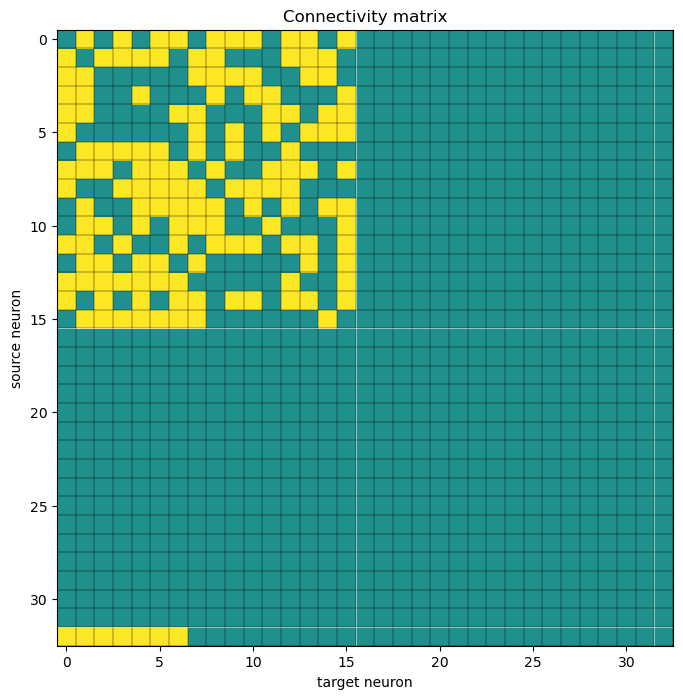

In [429]:
plt.clf()      # clear current figure
plt.close('all')  # close all existing figures

fig, ax = plt.subplots(figsize=(8, 8))

im = ax.imshow(
    C,
    interpolation='none',
    aspect='equal',
    vmin=-1,
    vmax=1
)
ax.set_xticks(np.arange(N_tot + 1) - 0.5, minor=True)
ax.set_yticks(np.arange(N_tot + 1) - 0.5, minor=True)

ax.grid(which='minor', color='black', linestyle='-', linewidth=0.3)

ax.tick_params(which='minor', bottom=False, left=False)

ax.axhline(NE * NS - 0.5, color='white', linewidth=0.4)
ax.axvline(NE * NS - 0.5, color='white', linewidth=0.4)

ax.axhline(N_hw - 0.5, color='white', linewidth=0.4)
ax.axvline(N_hw - 0.5, color='white', linewidth=0.4)

ax.set_xlabel("target neuron")
ax.set_ylabel("source neuron")

ax.set_title("Connectivity matrix")

In [430]:
# ------------------------------------------------------------
# APPLY CONFIGURATION
# ------------------------------------------------------------
new_config = net_gen.make_dynapse1_configuration()
model.apply_configuration(new_config)

set_params(model, param_group=param_group)

# ------------------------------------------------------------
# PREPARE POISSON INPUT
# ------------------------------------------------------------
global_poisson_gen_ids = ut.get_global_id_list(spikegen_ids)
poisson_gen            = model.get_poisson_gen()
poisson_gen.set_chip_id(0)

# set initial rates to zero
for gid in global_poisson_gen_ids:
    poisson_gen.write_poisson_rate_hz(gid, 0)

# ------------------------------------------------------------
# MONITOR NEURONS
# ------------------------------------------------------------
monitored_neurons = E_ids + I_ids
graph, filter_node, sink_node = ut.create_neuron_select_graph(model, monitored_neurons)
graph.start()
# filter_node.set_neurons(monitored_neurons)

# clear buffer
sink_node.get_events()
api.reset_timestamp()

New configuration applied to DYNAP-SE1!


In [431]:
# ------------------------------------------------------------
# CREATE POISSON SPIKE TIMES
# ------------------------------------------------------------
spike_times  = []
indices      = []
target_chips = []

t0 = 0.0

for i, duration in enumerate(t_steps_stim):

    for gen_id, rate in zip(global_poisson_gen_ids, stim_rates_hz[i]):

        n_spikes = np.random.poisson(rate * duration)
        
        times = t0 + np.sort(np.random.rand(n_spikes) * duration)
        
        spike_times.extend(times)
        indices.extend([gen_id] * n_spikes)
        target_chips.extend([0] * n_spikes)

    t0 += duration


# Then sort all spikes globally in time:
spike_times  = np.array(spike_times)
indices      = np.array(indices)
target_chips = np.array(target_chips)

sort_idx = np.argsort(spike_times)

spike_times  = spike_times[sort_idx]
indices      = indices[sort_idx]
target_chips = target_chips[sort_idx]


# Then load the stimulus:
fpga_spike_gen = model.get_fpga_spike_gen()

ut.set_fpga_spike_gen(
    fpga_spike_gen = fpga_spike_gen,
    spike_times    = spike_times,
    indices        = indices,
    target_chips   = target_chips,
    isi_base       = 900,
    repeat_mode    = False
)

VariableIsiMode already 1
RepeatMode already 0


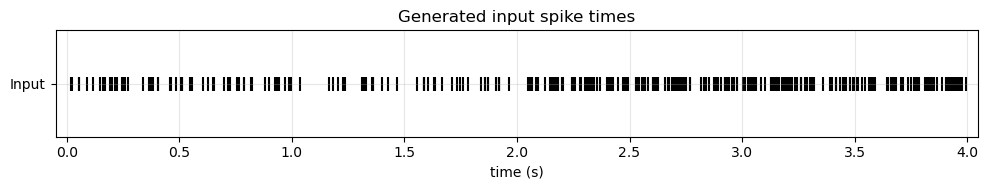

In [432]:
fig, ax = plt.subplots(figsize=(10, 2))

ax.scatter(
    spike_times,
    -1 * np.ones_like(spike_times),
    marker='|',
    s=100,
    color='black'
)

ax.set_xlabel('time (s)')
ax.set_yticks([-1])
ax.set_yticklabels(['Input'])
ax.set_title('Generated input spike times')
ax.set_xlim(-0.05, t0 + 0.05)

ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### **Run Simulation**

In [433]:
# Run Simulation
fpga_spike_gen.start()
time.sleep(t0)
fpga_spike_gen.stop()

# turn off stimulus

for gid in global_poisson_gen_ids:
    poisson_gen.write_poisson_rate_hz(gid, 0)

poisson_gen.stop()
time.sleep(t_tot)

graph.stop()
events = sink_node.get_events()

print(f"{len(events)} events recorded.")

PoissonGen already off!
238 events recorded.


### **Post Simulation Processing**

In [434]:
# ------------------------------------------------------------
# EXTRACT EVENTS
# ------------------------------------------------------------
spike_id = []
spike_t  = []

for evt in events:
    spike_id.append(evt.neuron_id)
    spike_t.append(evt.timestamp * 1e-6)

spike_id = np.array(spike_id)
spike_t  = np.array(spike_t)


# ------------------------------------------------------------
# FILTER SPIKES BY POPULATION
# ------------------------------------------------------------
S_spike_t  = []
S_spike_id = []

for s in range(int(NS)):
    lower = s * NE
    upper = (s + 1) * NE

    mask = (spike_id > lower) & (spike_id <= upper)

    S_spike_t.append(spike_t[mask])
    S_spike_id.append(spike_id[mask])

mask_I = spike_id > NS * NE

I_spike_t  = spike_t[mask_I]
I_spike_id = spike_id[mask_I]


# ------------------------------------------------------------
# BIN FILTERED SPIKES
# ------------------------------------------------------------
fs     = 1
n_bins = int(t_tot * fs)

binPOP = np.zeros((NS + 1, n_bins))

for s in range(int(NS + 1)):

    if s < NS:
        t_spikes = S_spike_t[s]
    else:
        t_spikes = I_spike_t   # last row = inhibitory population

    t_spikes = t_spikes[t_spikes < t_tot]

    counts, _ = np.histogram(
        t_spikes,
        bins=n_bins,
        range=(0, t_tot)
    )

    binPOP[s, :] = counts

# total excitatory activity (all S populations pooled)
binPOP_E = np.sum(binPOP[:NS, :], axis=0)

# Mean excitatory activity (all S populations pooled)
binPOP_tot_mean = np.sum(binPOP) / (NS * NE)


# ------------------------------------------------------------
# POPULATION FIRING ACTIVITY
# ------------------------------------------------------------
idx_end = int(t_tot * fs)
t_axis  = np.arange(idx_end) / fs

binPOP_rate = binPOP[:, :idx_end] * fs / NE

# ---------------------------------------------------------
# FIRING ACTIVITY PER STIMULUS WINDOW
# ------------------------------------------------------------

#TODO Make independent of binPOP

stim_start = np.cumsum(np.r_[0, t_steps_stim[:-1]])
stim_end   = stim_start + t_steps_stim

out_rates = np.zeros((NS, len(stim_rates)))

for s in range(int(NS)):
    for i, (t0, t1) in enumerate(zip(stim_start, stim_end)):
        b0 = int(t0 * fs)
        b1 = int(t1 * fs)

        n_spikes = np.sum(binPOP[s, b0:b1])

        out_rates[s, i] = n_spikes / (t1 - t0)




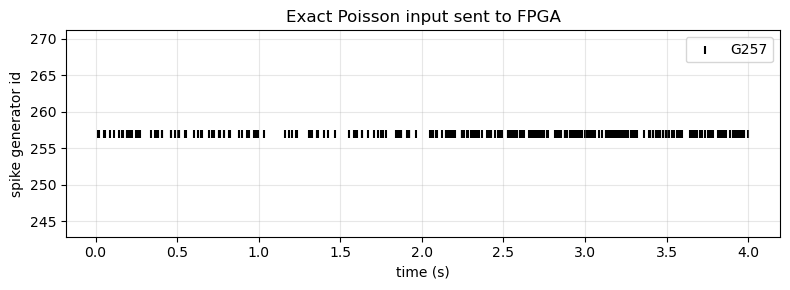

In [435]:
input_spike_t  = spike_times
input_spike_id = indices

color_in = 'black'

fig, ax = plt.subplots(figsize=(8, 3))

for gid in np.unique(input_spike_id):
    mask = input_spike_id == gid
    ax.scatter(
        input_spike_t[mask],
        input_spike_id[mask],
        marker='|',
        s = 30,
        color = color_in,
        label=f'G{gid}'
    )

ax.set_xlabel('time (s)')
ax.set_ylabel('spike generator id')
ax.set_title('Exact Poisson input sent to FPGA')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

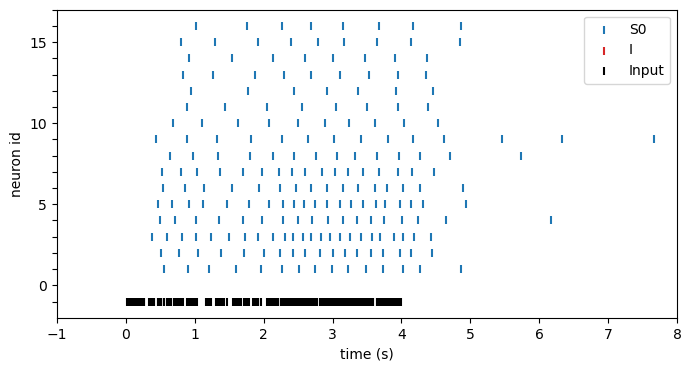

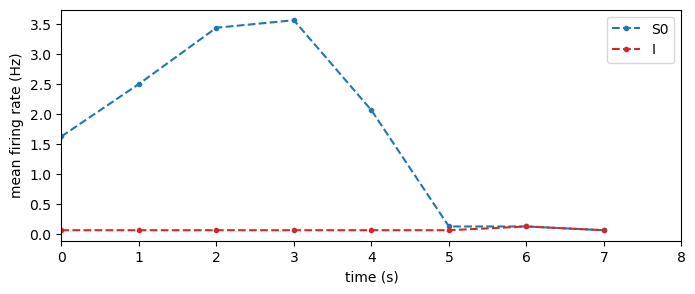

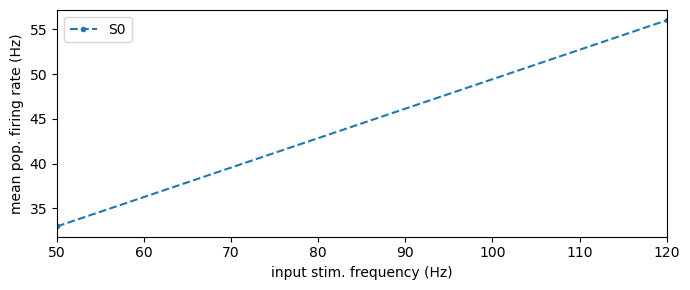

In [436]:
color_I  = 'tab:red'
color_S  = ['tab:blue', 'tab:orange', 'tab:green', color_I]  # one per S population

# ------------------------------------------------------------
# PLOT SPIKE RASTER
# ------------------------------------------------------------
fig1, ax1 = plt.subplots(figsize=(8, 4))

for s in range(int(NS)):
    ax1.scatter(
        S_spike_t[s],
        S_spike_id[s],
        marker='|',
        color=color_S[s],
        label=f'S{s}'
    )

if I_spike_t.size > 0:
     ax1.scatter(
        I_spike_t,
        I_spike_id,
        marker='|',
        color= color_I,
        label='I'
    )

ax1.scatter(
    input_spike_t,
    -1 * np.ones_like(input_spike_t),
    marker='|',
    color= color_in,
    label='Input'
)

ticks = np.arange(-NG, NS*NE + NI, 1)
#ticks = np.arange(0, NE, 1)
ax1.set_yticks(ticks)

# show labels only every k neurons
k = 5
labels = [str(t) if t % k == 0 else '' for t in ticks]
ax1.set_yticklabels(labels)

ax1.set_xlabel('time (s)')
ax1.set_ylabel('neuron id')
ax1.set_xlim(-1, t_tot)
ax1.set_ylim(-2,17)
ax1.legend()


# ------------------------------------------------------------
# PLOT FIRING ACTIVITY AGAINST TIME
# ------------------------------------------------------------
fig2, ax2 = plt.subplots(figsize=(8, 3))

for s in range(int(NS)):
    ax2.plot(
        t_axis,
        binPOP_rate[s],
        marker      = 'o',
        linestyle   = '--',
        color       = color_S[s],
        markersize  = 3,
        label       = f'S{s}'
    )

if I_spike_t.size > 0:
     ax2.plot(
            t_axis,
            binPOP_rate[NS],
            marker     = 'o',
            linestyle  = '--',
            color      = color_I,
            markersize = 3,
            label      = f'I'
        )

ax2.set_xlabel('time (s)')
ax2.set_ylabel('mean firing rate (Hz)')
ax2.set_xlim(0, t_tot)
ax2.legend()


# ------------------------------------------------------------
# PLOT FIRING ACTIVITY AGAINST INPUT STIMULUS
# ------------------------------------------------------------
fig3, ax3 = plt.subplots(figsize=(7, 3))

for s in range(int(NS)):
    ax3.plot(
        stim_rates,
        out_rates[s],
        marker='o',
        markersize=3,
        linestyle='--',
        label=f'S{s}'
    )

ax3.set_xlabel('input stim. frequency (Hz)')
ax3.set_ylabel('mean pop. firing rate (Hz)')
ax3.set_xlim(stim_rates[0], stim_rates[-1])
ax3.legend()

plt.tight_layout()
plt.show()

### **Plot Stimulation Rates**

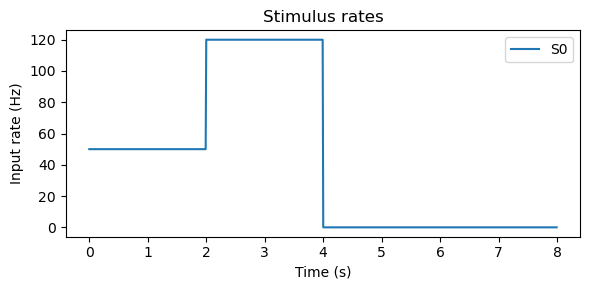

In [437]:

fs = 100

stim_rates_hz = np.array(stim_rates_hz)
t             = np.arange(0, t_tot, 1/fs)

# allocate rate matrix
rates = np.zeros((NS, len(t)))

# fill piecewise constant segments
t_cursor = 0
for i, dt in enumerate(t_steps_stim):
    idx_start = int(t_cursor * fs)
    idx_end   = int((t_cursor + dt) * fs)

    for s in range(NS):
        rates[s, idx_start:idx_end] = stim_rates_hz[i, s]

    t_cursor += dt

plt.figure(figsize=(6,3))

for s in range(NS):
    plt.plot(t, rates[s], label=f"S{s}")

plt.xlabel("Time (s)")
plt.ylabel("Input rate (Hz)")
plt.title("Stimulus rates")
plt.legend()
plt.tight_layout()
plt.show()


Misc

In [438]:
from tools.spikegen_tools import get_instantaneous_activity


# ------------------------------------------------------------
# INSTANTANEOUS POPULATION ACTIVITY
# ------------------------------------------------------------
activity_dt_s = 0.4
exp_tc_s      = 0.02


def population_activity(t_spikes, n_neurons):
    t_spikes = np.asarray(t_spikes, dtype=float)
    t_spikes = np.sort(t_spikes[(t_spikes >= 0) & (t_spikes < t_tot)])

    if len(t_spikes) == 0:
        activity_x    = np.arange(0, t_tot, activity_dt_s)
        activity_rate = np.zeros_like(activity_x)
        return activity_rate, activity_x

    activity_hz, activity_x = get_instantaneous_activity(
        t_spikes,
        activity_dt_s,
        exp_tc_s
    )

    activity_hz = np.asarray(activity_hz, dtype=float)
    activity_x  = np.asarray(activity_x, dtype=float)

    mask = activity_x < t_tot

    activity_rate = activity_hz[mask] / n_neurons
    activity_x    = activity_x[mask]

    return activity_rate, activity_x


S_activity_rate = []
S_activity_x    = []

for s in range(int(NS)):
    rate, x = population_activity(S_spike_t[s], NE)

    S_activity_rate.append(rate)
    S_activity_x.append(x)


I_activity_rate, I_activity_x = population_activity(I_spike_t, NI)


# total excitatory activity, all S populations pooled
E_spike_t = np.concatenate(S_spike_t)

E_activity_rate, E_activity_x = population_activity(
    E_spike_t,
    int(NS) * NE
)

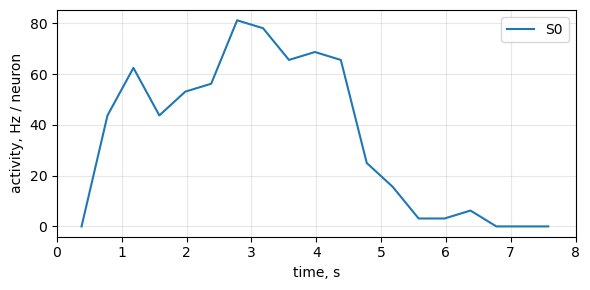

In [439]:
# ------------------------------------------------------------
# PLOT INSTANTANEOUS POPULATION ACTIVITY
# ------------------------------------------------------------
fig2, ax2 = plt.subplots(figsize=(6, 3))

for s in range(int(NS)):
    ax2.plot(
        S_activity_x[s],
        S_activity_rate[s],
        label=f"S{s}"
    )
"""
ax2.plot(
    I_activity_x,
    I_activity_rate,
    label="I"
)
"""

ax2.set_xlabel("time, s")
ax2.set_ylabel("activity, Hz / neuron")
ax2.set_xlim(0, t_tot)
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()